# **Setup & Import Library**

In [3]:
# ==========================================
# BLOK 1: SETUP DAN IMPORT LIBRARY
# ==========================================
import cv2
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from google.colab import drive

# Mount Google Drive (Akan meminta izin akses)
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Pre-Processing**

In [4]:
# Definisikan semua alamat folder
input_folder = '/content/drive/MyDrive/COMVIS/dataset_wajah'
output_folder = '/content/drive/MyDrive/COMVIS/dataset_wajah_resized'
vis_folder = '/content/drive/MyDrive/COMVIS/hasil_visualisasi'

# Buat folder jika belum ada
os.makedirs(output_folder, exist_ok=True)
os.makedirs(vis_folder, exist_ok=True)

print("--- Memulai Proses Pre-processing (Resize 256x256) ---")
gambar_ditemukan = False

for filename in os.listdir(input_folder):
    if filename.lower().endswith((".jpg", ".png", ".jpeg")):
        img_path = os.path.join(input_folder, filename)
        img = cv2.imread(img_path)

        if img is not None:
            # Resize ke resolusi standar 256x256
            resized = cv2.resize(img, (256, 256))
            cv2.imwrite(os.path.join(output_folder, filename), resized)
            print(f"✅ Resize berhasil: {filename}")
            gambar_ditemukan = True
        else:
            print(f"❌ Gagal membaca: {filename}")

if not gambar_ditemukan:
    print("⚠️ Peringatan: Tidak ada gambar ditemukan di folder input!")
else:
    print("--- Pre-processing Selesai ---")

--- Memulai Proses Pre-processing (Resize 256x256) ---
✅ Resize berhasil: IMG_20250504_154431 (1).jpg
✅ Resize berhasil: 147.jpg
✅ Resize berhasil: 307.jpg
✅ Resize berhasil: 270.jpg
✅ Resize berhasil: 91.jpg
✅ Resize berhasil: 95.jpg
✅ Resize berhasil: 242.jpg
✅ Resize berhasil: 220.jpg
✅ Resize berhasil: 5.jpg
✅ Resize berhasil: 243.jpg
--- Pre-processing Selesai ---


# **EKSTRAKSI FITUR (BENTUK & WARNA) DAN VISUALISASI**

--- Memulai Ekstraksi Fitur ---

Memproses: IMG_20250504_154431 (1).jpg


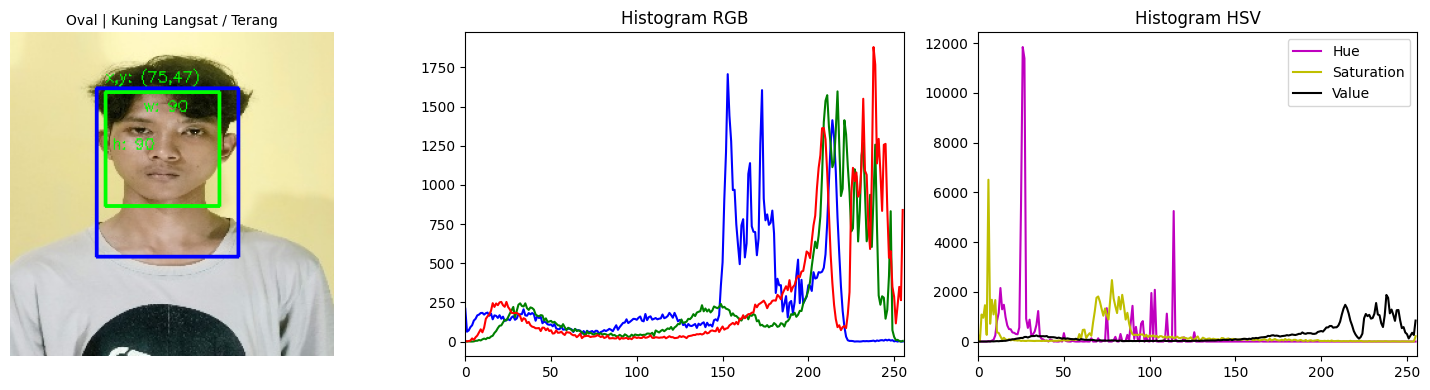


Memproses: 147.jpg


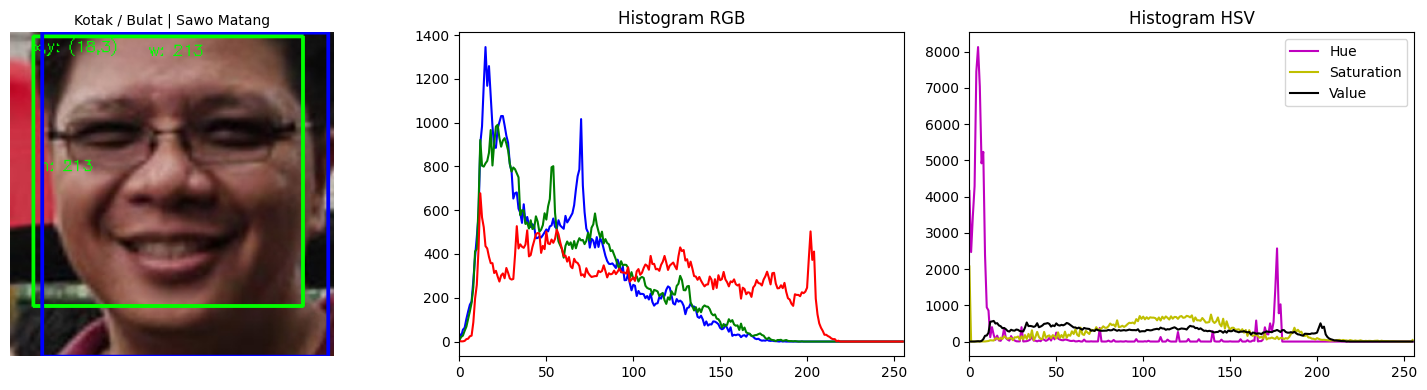


Memproses: 307.jpg


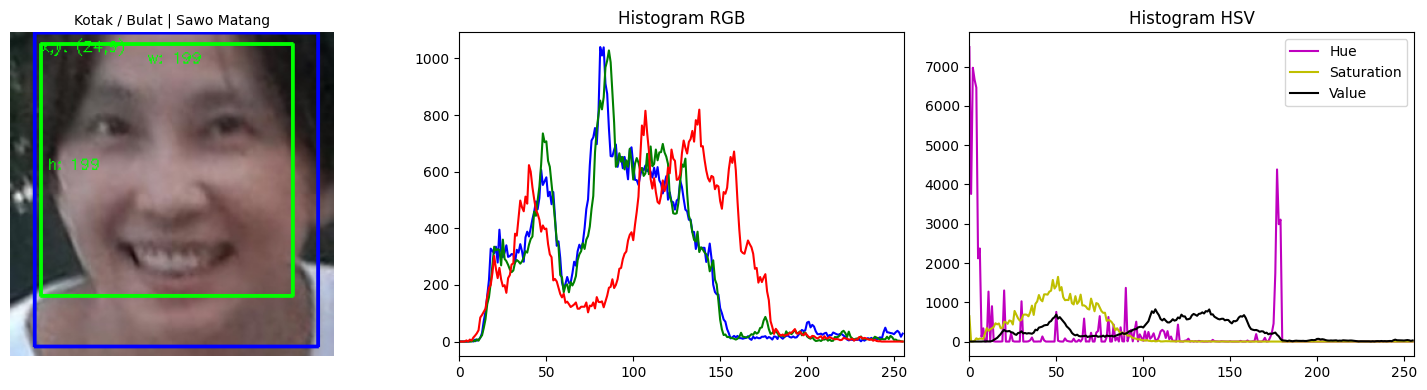


Memproses: 270.jpg


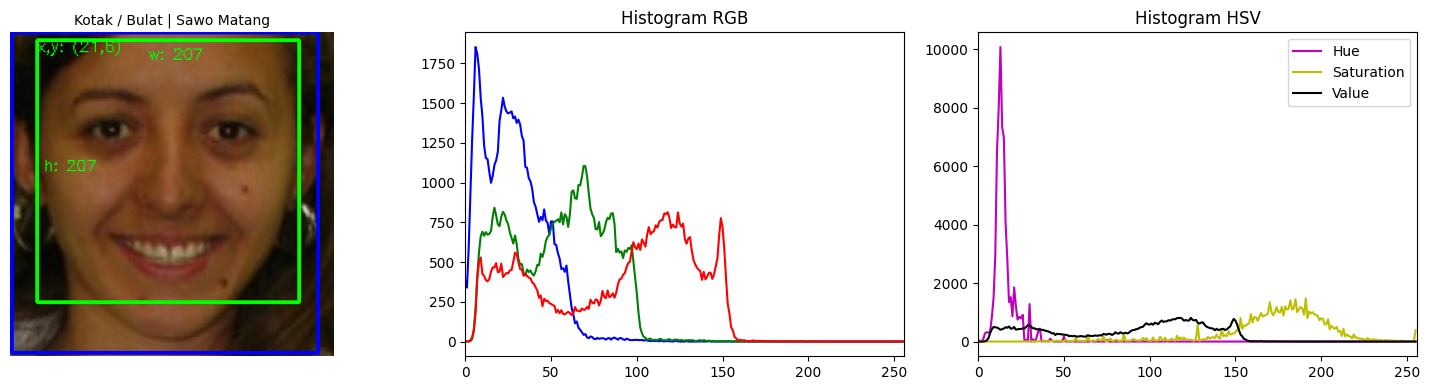


Memproses: 91.jpg


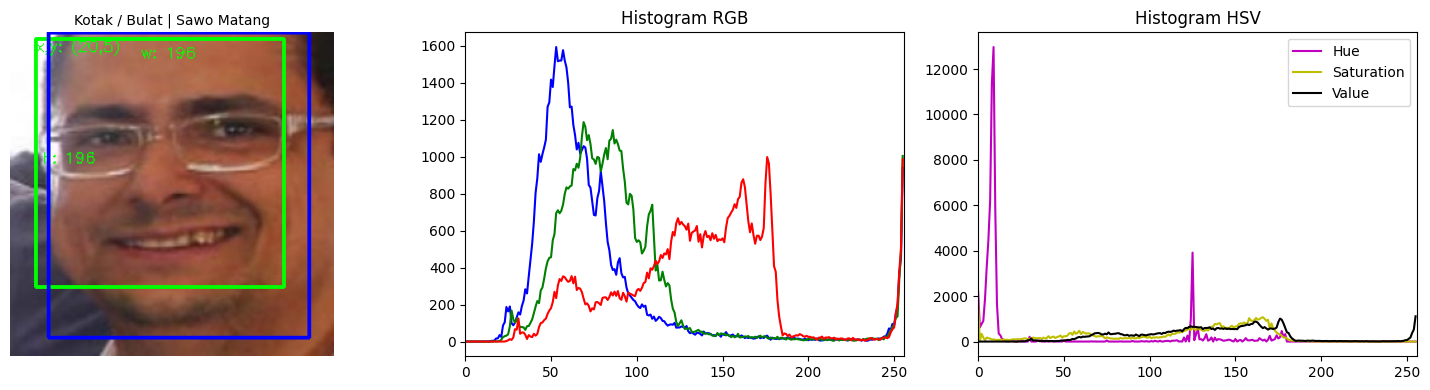


Memproses: 95.jpg


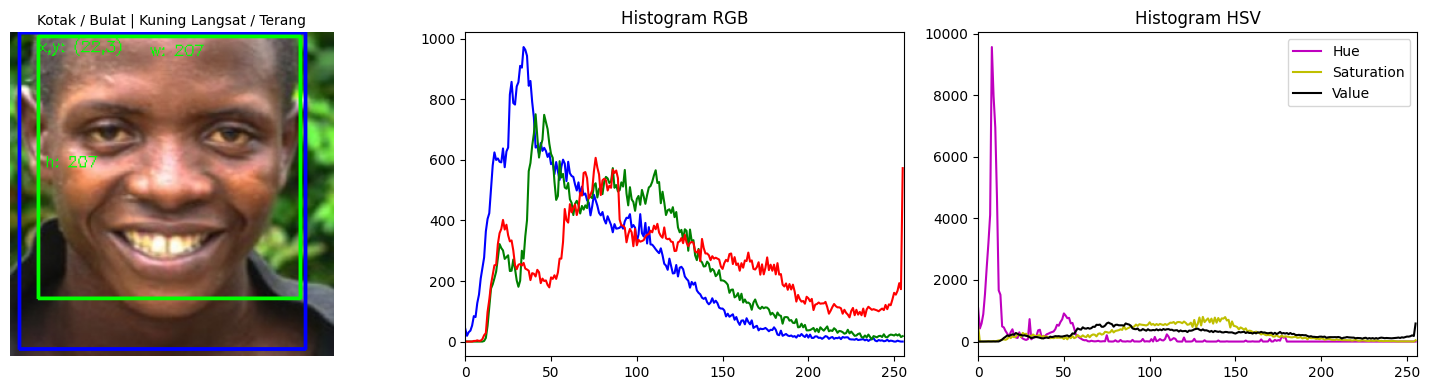


Memproses: 242.jpg


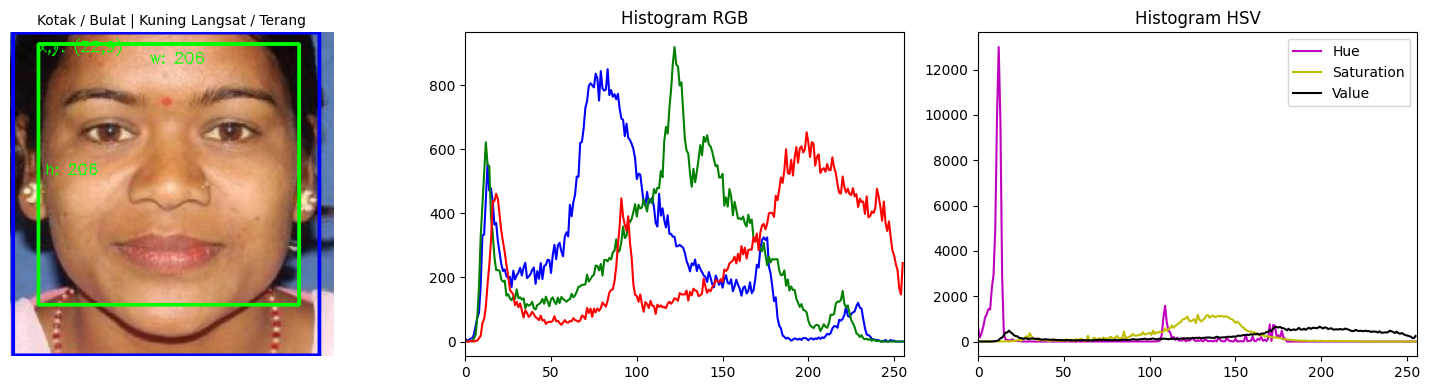


Memproses: 220.jpg


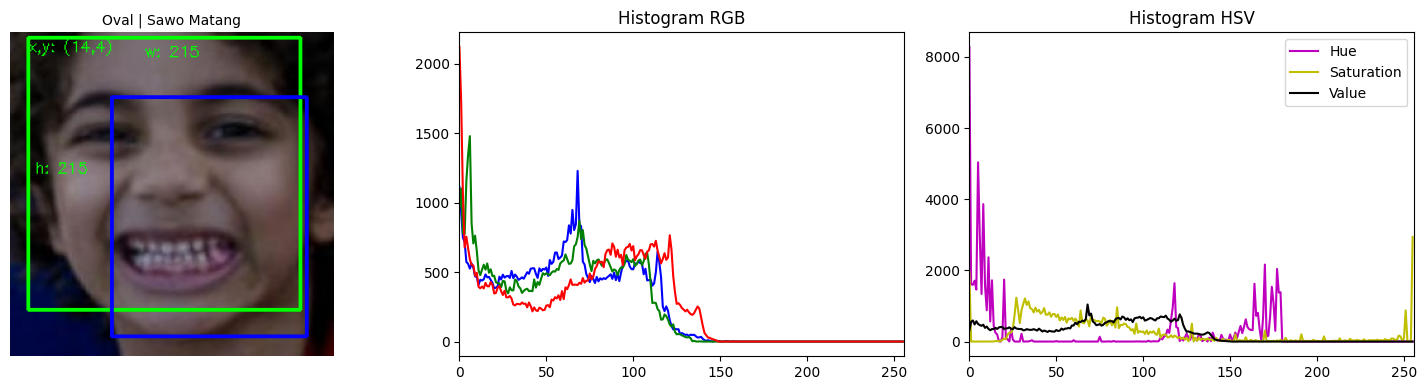


Memproses: 5.jpg


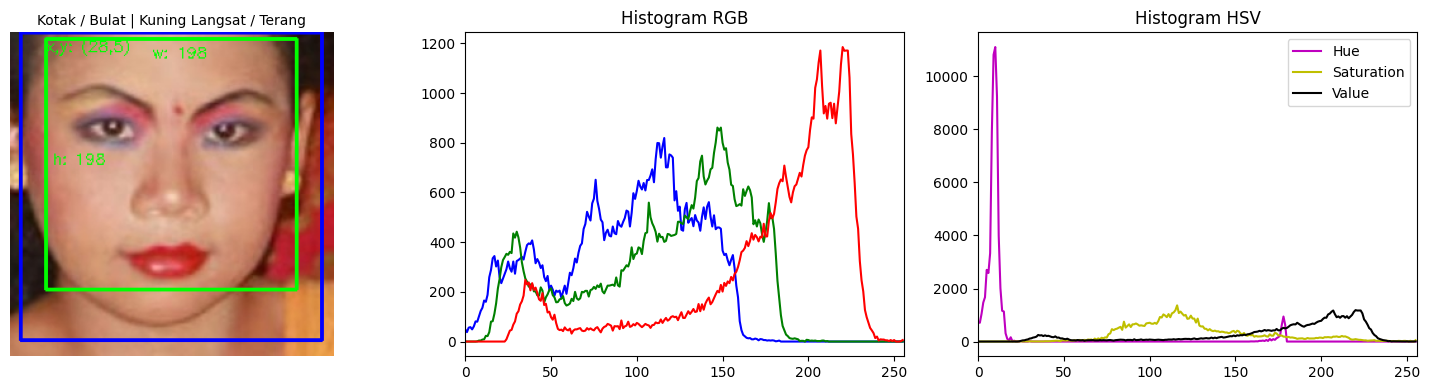


Memproses: 243.jpg


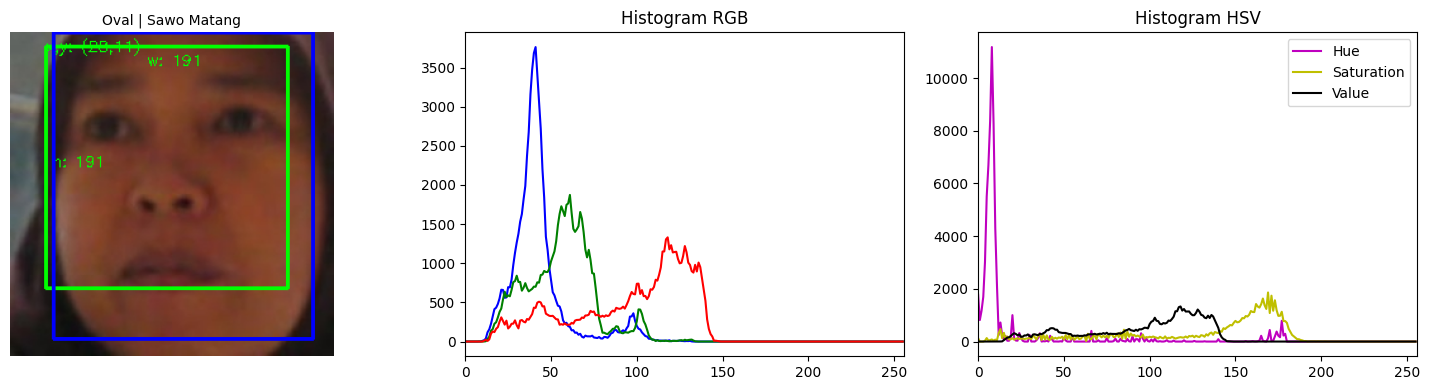


--- Ekstraksi dan Visualisasi Selesai ---


In [5]:
print("--- Memulai Ekstraksi Fitur ---")
data_ekstraksi = []

# Load model Haar Cascade
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

for filename in os.listdir(output_folder):
    if filename.lower().endswith((".jpg", ".png", ".jpeg")):
        file_path = os.path.join(output_folder, filename)
        img = cv2.imread(file_path)
        if img is None: continue

        print(f"\nMemproses: {filename}")
        row_data = {'Nama_File': filename}
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        hsv_full = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4)

        img_vis = img.copy()

        if len(faces) > 0:
            x, y, w, h = faces[0]

            # --- 1. Ekstraksi Warna (Region of Interest) ---
            center_y, center_x = y + h//2, x + w//2
            offset = int(w * 0.15)
            skin_roi = img[center_y-offset : center_y+offset, center_x-offset : center_x+offset]

            if skin_roi.size > 0:
                hsv_roi = cv2.cvtColor(skin_roi, cv2.COLOR_BGR2HSV)
                v_mean = np.mean(hsv_roi[:,:,2])
                row_data['R_Mean'], row_data['G_Mean'], row_data['B_Mean'] = np.mean(skin_roi[:,:,2]), np.mean(skin_roi[:,:,1]), np.mean(skin_roi[:,:,0])
                row_data['H_Mean'], row_data['S_Mean'], row_data['V_Mean'] = np.mean(hsv_roi[:,:,0]), np.mean(hsv_roi[:,:,1]), v_mean

                if v_mean > 160: kategori_kulit = "Kuning Langsat / Terang"
                elif 100 < v_mean <= 160: kategori_kulit = "Sawo Matang"
                else: kategori_kulit = "Gelap"
            else:
                kategori_kulit = "Gagal Ekstrak"

            row_data['Kategori_Warna_Kulit'] = kategori_kulit

            # Gambar kotak wajah & anotasi teks (Sesuai slide presentasi)
            cv2.rectangle(img_vis, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(img_vis, f'x,y: ({x},{y})', (x, max(15, y-8)), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)
            cv2.putText(img_vis, f'w: {w}', (x + w//2 - 15, y + 15), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)
            cv2.putText(img_vis, f'h: {h}', (x + 5, y + h//2), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

            # --- 2. Ekstraksi Bentuk (Skin Segmentation) ---
            lower_skin = np.array([0, 20, 70], dtype=np.uint8)
            upper_skin = np.array([20, 255, 255], dtype=np.uint8)
            skin_mask = cv2.inRange(hsv_full, lower_skin, upper_skin)
            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
            skin_mask = cv2.morphologyEx(skin_mask, cv2.MORPH_OPEN, kernel)

            mask_roi = skin_mask[max(0, y-20):min(img.shape[0], y+h+40), max(0, x-20):min(img.shape[1], x+w+20)]
            contours, _ = cv2.findContours(mask_roi, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            if contours:
                largest_contour = max(contours, key=cv2.contourArea)
                cx, cy, cw, ch = cv2.boundingRect(largest_contour)
                aspect_ratio = cw / float(ch)
                row_data['BBox_Width'], row_data['BBox_Height'] = cw, ch

                if aspect_ratio >= 0.85: kategori_bentuk = "Kotak / Bulat"
                elif 0.70 <= aspect_ratio < 0.85: kategori_bentuk = "Oval"
                else: kategori_bentuk = "Lonjong / Diamond"

                row_data['Kategori_Bentuk_Wajah'] = kategori_bentuk

                # Kotak biru untuk bentuk proporsi sesungguhnya
                real_cx, real_cy = cx + max(0, x-20), cy + max(0, y-20)
                cv2.rectangle(img_vis, (real_cx, real_cy), (real_cx+cw, real_cy+ch), (255, 0, 0), 2)
            else:
                row_data['Kategori_Bentuk_Wajah'] = "Kontur Gagal"
                row_data['BBox_Width'] = row_data['BBox_Height'] = 0
        else:
            row_data['Kategori_Bentuk_Wajah'] = "Wajah Tidak Terdeteksi"
            row_data['Kategori_Warna_Kulit'] = "Wajah Tidak Terdeteksi"
            cols = ['R_Mean', 'G_Mean', 'B_Mean', 'H_Mean', 'S_Mean', 'V_Mean', 'BBox_Width', 'BBox_Height']
            for c in cols: row_data[c] = 0

        data_ekstraksi.append(row_data)

        # --- 3. Pembuatan Grafik & Export Gambar ---
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        img_rgb = cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB)
        axes[0].imshow(img_rgb)
        axes[0].set_title(f"{kategori_bentuk} | {kategori_kulit}", fontsize=10)
        axes[0].axis('off')

        colors_rgb = ('b', 'g', 'r')
        for i, col in enumerate(colors_rgb):
            hist_rgb = cv2.calcHist([img], [i], None, [256], [0, 256])
            axes[1].plot(hist_rgb, color=col)
        axes[1].set_title("Histogram RGB")
        axes[1].set_xlim([0, 256])

        colors_hsv = ('m', 'y', 'k')
        labels_hsv = ('Hue', 'Saturation', 'Value')
        for i, col in enumerate(colors_hsv):
            hist_hsv = cv2.calcHist([hsv_full], [i], None, [256], [0, 256])
            axes[2].plot(hist_hsv, color=col, label=labels_hsv[i])
        axes[2].set_title("Histogram HSV")
        axes[2].set_xlim([0, 256])
        axes[2].legend()

        plt.tight_layout()
        vis_path = os.path.join(vis_folder, f"analisis_{filename}")
        plt.savefig(vis_path, dpi=150)
        plt.show()
        plt.close()

print("\n--- Ekstraksi dan Visualisasi Selesai ---")

# **PENYIMPANAN DATA KE EXCEL**

In [6]:
# ==========================================
# BLOK 4: PENYIMPANAN DATA KE EXCEL
# ==========================================
# Konversi data menjadi struktur tabel Pandas
df = pd.DataFrame(data_ekstraksi)

# Rapikan urutan kolom (Geser Kategori ke depan)
cols = df.columns.tolist()
if 'Kategori_Warna_Kulit' in cols and 'Kategori_Bentuk_Wajah' in cols:
    cols.insert(1, cols.pop(cols.index('Kategori_Warna_Kulit')))
    cols.insert(2, cols.pop(cols.index('Kategori_Bentuk_Wajah')))
df = df[cols]

# Simpan ke Google Drive
output_excel_path = '/content/drive/MyDrive/COMVIS/Hasil_Ekstraksi_Final.xlsx'
df.to_excel(output_excel_path, index=False, engine='openpyxl')

print(f"✅ Tahap Akhir Selesai!")
print(f"Data tabular telah disimpan di: {output_excel_path}")

# Tampilkan 5 baris pertama data di layar Colab sebagai konfirmasi
df.head()

✅ Tahap Akhir Selesai!
Data tabular telah disimpan di: /content/drive/MyDrive/COMVIS/Hasil_Ekstraksi_Final.xlsx


,Nama_File,Kategori_Warna_Kulit,Kategori_Bentuk_Wajah,R_Mean,G_Mean,B_Mean,H_Mean,S_Mean,V_Mean,BBox_Width,BBox_Height
0,IMG_20250504_154431 (1).jpg,Kuning Langsat / Terang,Oval,170.022189,134.167160,105.881657,13.220414,99.690828,170.022189,112,133
1,147.jpg,Sawo Matang,Kotak / Bulat,117.711759,75.310614,69.652185,17.790062,116.717742,117.711759,226,256
2,307.jpg,Sawo Matang,Kotak / Bulat,155.734542,128.269322,128.472652,79.736623,47.119203,155.734542,224,248
3,270.jpg,Sawo Matang,Kotak / Bulat,121.455775,67.564776,32.508845,11.729709,187.892820,121.455775,242,253
4,91.jpg,Sawo Matang,Kotak / Bulat,146.095422,86.603448,69.003864,7.617420,133.313615,146.095422,206,241
